## Load Data and Drop Channel and Snipping

In [1]:
import numpy as np

data = np.load("Datasets/Main.npz")
X = data["X_raw"]
y = data["y"]  

BAD_CHANNELS = [0]
X = np.delete(X, BAD_CHANNELS, axis=1)
print(X.shape)


(330, 7, 1750)


## Bandpassing

In [2]:
import numpy as np
from brainflow.data_filter import (
    DataFilter,
    FilterTypes,
    DetrendOperations
)

SAMPLING_RATE = 250  
LOW_CUT = 5
HIGH_CUT = 30
FILTER_ORDER = 4

X_filtered = np.copy(X)

for trial in range(X.shape[0]):

    for ch in range(X.shape[1]):

        signal = X_filtered[trial, ch]
        signal = np.ascontiguousarray(
            signal,
            dtype=np.float64
        )

        # Remove DC offset
        DataFilter.detrend(
            signal,
            DetrendOperations.CONSTANT.value
        )

        # 3–45 Hz Bandpass
        DataFilter.perform_bandpass(
            signal,
            SAMPLING_RATE,
            LOW_CUT,
            HIGH_CUT,
            FILTER_ORDER,
            FilterTypes.BUTTERWORTH_ZERO_PHASE.value,
            0
        )

        DataFilter.remove_environmental_noise(
            signal,
            SAMPLING_RATE,
            1
        )

        X_filtered[trial, ch] = signal

print("Original Shape :", X.shape)
print("Filtered Shape :", X_filtered.shape)

X = X_filtered

c:\Stored Data\BrainDance\venv\Lib\site-packages\brainflow\board_shim.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Original Shape : (330, 7, 1750)
Filtered Shape : (330, 7, 1750)


## Data Snipping

In [3]:
X_snipped = X[:, :, 500:-250]
X = X_snipped
print("Original Shape :", X.shape)
print("Snipped Shape  :", X_snipped.shape)

Original Shape : (330, 7, 1000)
Snipped Shape  : (330, 7, 1000)


## Noisy Trial Rejection

In [4]:
import numpy as np

def reject_noisy_trials(
    X,
    y,
    max_abs_thresh=250,
    ptp_thresh=500,
    std_z_thresh=3.0,
    flat_std_thresh=1e-6,
    verbose=True
):
    """
    X shape: (trials, channels, samples)
    y shape: (trials,)
    """

    # =========================
    # TRIAL / CHANNEL STATS
    # =========================

    max_abs = np.max(np.abs(X), axis=2)    # (trials, channels)
    ptp = np.ptp(X, axis=2)                # (trials, channels)
    std = np.std(X, axis=2)                # (trials, channels)

    trial_max_abs = np.max(max_abs, axis=1)
    trial_ptp = np.max(ptp, axis=1)
    trial_mean_std = np.mean(std, axis=1)

    median_std = np.median(trial_mean_std)
    mad_std = np.median(np.abs(trial_mean_std - median_std)) + 1e-12
    robust_z_std = 0.6745 * (trial_mean_std - median_std) / mad_std

    # =========================
    # REJECTION REASONS
    # =========================

    reason_max_abs = trial_max_abs > max_abs_thresh
    reason_ptp = trial_ptp > ptp_thresh
    reason_std_z = np.abs(robust_z_std) > std_z_thresh
    reason_flat = np.any(std < flat_std_thresh, axis=1)

    reject_mask = (
        reason_max_abs |
        reason_ptp |
        reason_std_z |
        reason_flat
    )

    keep_mask = ~reject_mask

    X_clean = X[keep_mask]
    y_clean = y[keep_mask]

    # =========================
    # SUMMARY
    # =========================

    if verbose:
        print("=" * 60)
        print("TRIAL REJECTION SUMMARY")
        print("=" * 60)

        print("Original trials :", len(X))
        print("Rejected trials :", int(np.sum(reject_mask)))
        print("Remaining trials:", len(X_clean))

        print("\nRejection reason counts:")
        print("Max abs exceeded :", int(np.sum(reason_max_abs)))
        print("PTP exceeded     :", int(np.sum(reason_ptp)))
        print("STD z-score bad  :", int(np.sum(reason_std_z)))
        print("Flat signal      :", int(np.sum(reason_flat)))

        print("\nRejected trial details:")
        rejected_indices = np.where(reject_mask)[0]

        if len(rejected_indices) == 0:
            print("None")
        else:
            for idx in rejected_indices:
                reasons = []

                if reason_max_abs[idx]:
                    reasons.append(
                        f"max_abs={trial_max_abs[idx]:.2f} > {max_abs_thresh}"
                    )

                if reason_ptp[idx]:
                    reasons.append(
                        f"ptp={trial_ptp[idx]:.2f} > {ptp_thresh}"
                    )

                if reason_std_z[idx]:
                    reasons.append(
                        f"std_z={robust_z_std[idx]:+.2f} > ±{std_z_thresh}"
                    )

                if reason_flat[idx]:
                    flat_channels = np.where(std[idx] < flat_std_thresh)[0]
                    reasons.append(
                        f"flat channels={flat_channels.tolist()}"
                    )

                print(f"Trial {idx}: " + " | ".join(reasons))

        print("\nClass balance before:")
        print(dict(zip(*np.unique(y, return_counts=True))))

        print("\nClass balance after:")
        print(dict(zip(*np.unique(y_clean, return_counts=True))))

    return {
        "X_clean": X_clean,
        "y_clean": y_clean,
        "keep_mask": keep_mask,
        "reject_mask": reject_mask,

        "reasons": {
            "max_abs": reason_max_abs,
            "ptp": reason_ptp,
            "std_z": reason_std_z,
            "flat": reason_flat,
        },

        "stats": {
            "trial_max_abs": trial_max_abs,
            "trial_ptp": trial_ptp,
            "trial_mean_std": trial_mean_std,
            "robust_z_std": robust_z_std,
        }
    }


result = reject_noisy_trials(
    X,
    y,
    max_abs_thresh=400,
    ptp_thresh=700,
    std_z_thresh=3.0
)

X = result["X_clean"]
y = result["y_clean"]

keep_mask = result["keep_mask"]
reject_mask = result["reject_mask"]
reasons = result["reasons"]
stats = result["stats"]

TRIAL REJECTION SUMMARY
Original trials : 330
Rejected trials : 30
Remaining trials: 300

Rejection reason counts:
Max abs exceeded : 1
PTP exceeded     : 0
STD z-score bad  : 30
Flat signal      : 0

Rejected trial details:
Trial 8: std_z=+4.02 > ±3.0
Trial 29: std_z=+7.05 > ±3.0
Trial 30: std_z=+4.46 > ±3.0
Trial 48: std_z=+5.61 > ±3.0
Trial 49: std_z=+4.33 > ±3.0
Trial 60: std_z=+5.15 > ±3.0
Trial 65: std_z=+4.28 > ±3.0
Trial 66: std_z=+7.78 > ±3.0
Trial 104: std_z=+8.77 > ±3.0
Trial 106: std_z=+5.75 > ±3.0
Trial 107: max_abs=402.89 > 400 | std_z=+22.33 > ±3.0
Trial 127: std_z=+6.18 > ±3.0
Trial 131: std_z=+4.85 > ±3.0
Trial 157: std_z=+6.23 > ±3.0
Trial 194: std_z=+8.88 > ±3.0
Trial 204: std_z=+4.29 > ±3.0
Trial 212: std_z=+4.91 > ±3.0
Trial 221: std_z=+7.69 > ±3.0
Trial 228: std_z=+8.17 > ±3.0
Trial 236: std_z=+6.31 > ±3.0
Trial 260: std_z=+6.13 > ±3.0
Trial 264: std_z=+9.65 > ±3.0
Trial 269: std_z=+3.65 > ±3.0
Trial 278: std_z=+7.17 > ±3.0
Trial 294: std_z=+12.04 > ±3.0
Trial 296

## Train Test Val Split

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,   # 70% train
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,   # 15% val, 15% test
    random_state=42,
    stratify=y_temp
)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print()

print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

print("\nTrain class balance:")
print(np.unique(y_train, return_counts=True))

print("\nValidation class balance:")
print(np.unique(y_val, return_counts=True))

print("\nTest class balance:")
print(np.unique(y_test, return_counts=True))

X_train shape: (210, 7, 1000)
X_val shape  : (45, 7, 1000)
X_test shape : (45, 7, 1000)

y_train shape: (210,)
y_val shape  : (45,)
y_test shape : (45,)

Train class balance:
(array([1, 2]), array([104, 106]))

Validation class balance:
(array([1, 2]), array([22, 23]))

Test class balance:
(array([1, 2]), array([22, 23]))


## Feature Extraction

In [6]:
import time
import math
import logging
import numpy as np

from scipy.signal import welch, coherence, hilbert
from scipy.stats import skew, kurtosis, entropy
from scipy.linalg import eigh
from sklearn.preprocessing import StandardScaler

try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

try:
    import pywt
    HAS_PYWT = True
except ImportError:
    HAS_PYWT = False


# ============================================================
# CONFIG
# ============================================================

FS = 250

# After dropping original channel 0:
# [C1, C2, C3, Cz, C4, C5, C6]
C3_IDX = 2
CZ_IDX = 3
C4_IDX = 4

FAST_MODE = False  # Set to True to skip expensive features for quick testing

CONFIG = {
    # Core useful stuff
    "use_original_channels": True,
    "use_bipolar": True,
    "use_laplacian": True,
    "use_csp": True,

    # Feature groups
    "use_basic_time_features": True,
    "use_hjorth": True,
    "use_higher_order_stats": True,
    "use_bandpowers": True,
    "use_spectral_shape": True,
    "use_ratios": True,
    "use_differential_entropy": True,
    "use_wavelets": False,

    # Expensive / risky
    "use_higuchi_fd": False,
    "use_permutation_entropy": True,
    "use_connectivity": False,
    "use_coherence": False,
    "use_plv_pli": False,
    "use_crosscorr": False,

    # Logging
    "log_every_n_trials": 10,
}

if not FAST_MODE:
    CONFIG["use_wavelets"] = True
    CONFIG["use_higuchi_fd"] = True
    CONFIG["use_connectivity"] = True
    CONFIG["use_coherence"] = True
    CONFIG["use_plv_pli"] = True
    CONFIG["use_crosscorr"] = True


BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "mu": (8, 13),
    "alpha": (8, 12),
    "low_beta": (13, 20),
    "high_beta": (20, 30),
    "beta": (13, 30),
    "gamma": (30, 45),
    "broad": (1, 45),
    "mi": (8, 30),
    "smr": (12, 15),
    "low_gamma": (30, 38),
    "high_gamma": (38, 45),
}


# ============================================================
# LOGGING
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] %(levelname)s - %(message)s",
    datefmt="%H:%M:%S"
)

logger = logging.getLogger("EEGFeatureBomb")


def progress(iterable, desc=""):
    if HAS_TQDM:
        return tqdm(iterable, desc=desc)
    return iterable


def log_config():
    logger.info("========== EEG FEATURE BOMB CONFIG ==========")
    logger.info(f"FAST_MODE: {FAST_MODE}")
    logger.info(f"PyWavelets available: {HAS_PYWT}")
    logger.info(f"tqdm available: {HAS_TQDM}")

    for k, v in CONFIG.items():
        logger.info(f"{k}: {v}")

    logger.info("Bands:")
    for name, band in BANDS.items():
        logger.info(f"  {name}: {band}")
    logger.info("=============================================")


# ============================================================
# SAFETY HELPERS
# ============================================================

def safe_value(x):
    try:
        if np.isnan(x) or np.isinf(x):
            return 0.0
        return float(x)
    except Exception:
        return 0.0


def safe_log(x):
    return np.log(float(x) + 1e-12)


def safe_array(x):
    return np.nan_to_num(
        np.asarray(x, dtype=np.float64),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )


# ============================================================
# PSD / SPECTRAL HELPERS
# ============================================================

def welch_psd(signal, fs):
    signal = safe_array(signal)

    freqs, psd = welch(
        signal,
        fs=fs,
        nperseg=min(256, len(signal)),
        noverlap=min(128, len(signal) // 2)
    )

    psd = np.nan_to_num(psd, nan=0.0, posinf=0.0, neginf=0.0)
    return freqs, psd + 1e-12


def bandpower_from_psd(freqs, psd, low, high):
    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask):
        return 0.0

    return safe_value(np.mean(psd[mask]))


def spectral_entropy_from_psd(psd):
    p = psd / (np.sum(psd) + 1e-12)
    h = -np.sum(p * np.log2(p + 1e-12))
    h /= np.log2(len(p) + 1e-12)
    return safe_value(h)


def spectral_flatness(psd):
    geo = np.exp(np.mean(np.log(psd + 1e-12)))
    arith = np.mean(psd + 1e-12)
    return safe_value(geo / arith)


def spectral_centroid(freqs, psd):
    return safe_value(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))


def spectral_bandwidth(freqs, psd):
    c = spectral_centroid(freqs, psd)
    return safe_value(
        np.sqrt(np.sum(((freqs - c) ** 2) * psd) / (np.sum(psd) + 1e-12))
    )


def spectral_edge_frequency(freqs, psd, edge=0.95):
    cumsum = np.cumsum(psd)

    if cumsum[-1] <= 0:
        return 0.0

    threshold = edge * cumsum[-1]
    idx = np.searchsorted(cumsum, threshold)
    idx = min(idx, len(freqs) - 1)

    return safe_value(freqs[idx])


def dominant_frequency(freqs, psd, low=1, high=45):
    mask = (freqs >= low) & (freqs <= high)

    if not np.any(mask):
        return 0.0

    local_freqs = freqs[mask]
    local_psd = psd[mask]

    return safe_value(local_freqs[np.argmax(local_psd)])


# ============================================================
# TIME / NONLINEAR FEATURES
# ============================================================

def hjorth_parameters(signal):
    x = safe_array(signal)

    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x)
    var1 = np.var(dx)
    var2 = np.var(ddx)

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-12))
    complexity = np.sqrt(var2 / (var1 + 1e-12)) / (mobility + 1e-12)

    return (
        safe_value(activity),
        safe_value(mobility),
        safe_value(complexity)
    )


def zero_crossing_rate(signal):
    x = safe_array(signal)
    return safe_value(np.mean(np.diff(np.signbit(x)) != 0))


def line_length(signal):
    x = safe_array(signal)
    return safe_value(np.sum(np.abs(np.diff(x))))


def teager_kaiser_energy(signal):
    x = safe_array(signal)

    if len(x) < 3:
        return 0.0

    tke = x[1:-1] ** 2 - x[:-2] * x[2:]
    return safe_value(np.mean(np.abs(tke)))


def permutation_entropy(signal, order=3, delay=1):
    x = safe_array(signal)
    n = len(x)

    if n < order * delay:
        return 0.0

    patterns = {}

    for i in range(n - delay * (order - 1)):
        window = x[i:i + delay * order:delay]
        pattern = tuple(np.argsort(window))
        patterns[pattern] = patterns.get(pattern, 0) + 1

    counts = np.array(list(patterns.values()), dtype=float)
    probs = counts / (np.sum(counts) + 1e-12)

    h = -np.sum(probs * np.log2(probs + 1e-12))
    h /= np.log2(math.factorial(order))

    return safe_value(h)


def petrosian_fd(signal):
    x = safe_array(signal)

    if len(x) < 3:
        return 0.0

    diff = np.diff(x)
    n_delta = np.sum(diff[1:] * diff[:-1] < 0)
    n = len(x)

    return safe_value(
        np.log10(n) /
        (np.log10(n) + np.log10(n / (n + 0.4 * n_delta + 1e-12)))
    )


def higuchi_fd(signal, kmax=6):
    x = safe_array(signal)
    n = len(x)

    lk = []
    k_values = range(1, kmax + 1)

    for k in k_values:
        lm = []

        for m in range(k):
            idx = np.arange(m, n, k)

            if len(idx) < 2:
                continue

            length = np.sum(np.abs(np.diff(x[idx])))
            norm = (n - 1) / (((len(idx) - 1) * k) + 1e-12)
            lm.append(length * norm)

        if len(lm) > 0:
            lk.append(np.mean(lm))

    if len(lk) < 2:
        return 0.0

    lk = np.array(lk)
    k_values = np.array(list(k_values[:len(lk)]))

    coeffs = np.polyfit(np.log(1.0 / k_values), np.log(lk + 1e-12), 1)

    return safe_value(coeffs[0])


# ============================================================
# CONNECTIVITY FEATURES
# ============================================================

def phase_locking_value(x, y):
    x = safe_array(x)
    y = safe_array(y)

    hx = hilbert(x)
    hy = hilbert(y)

    phase_x = np.angle(hx)
    phase_y = np.angle(hy)

    plv = np.abs(np.mean(np.exp(1j * (phase_x - phase_y))))
    return safe_value(plv)


def phase_lag_index(x, y):
    x = safe_array(x)
    y = safe_array(y)

    hx = hilbert(x)
    hy = hilbert(y)

    phase_x = np.angle(hx)
    phase_y = np.angle(hy)

    phase_diff = phase_x - phase_y
    pli = np.abs(np.mean(np.sign(np.sin(phase_diff))))

    return safe_value(pli)


def max_crosscorr_lag(x, y, max_lag=25):
    x = safe_array(x)
    y = safe_array(y)

    x = (x - np.mean(x)) / (np.std(x) + 1e-12)
    y = (y - np.mean(y)) / (np.std(y) + 1e-12)

    corrs = []
    lags = range(-max_lag, max_lag + 1)

    for lag in lags:
        if lag < 0:
            corr = np.mean(x[:lag] * y[-lag:])
        elif lag > 0:
            corr = np.mean(x[lag:] * y[:-lag])
        else:
            corr = np.mean(x * y)

        corrs.append(corr)

    corrs = np.array(corrs)
    best_idx = np.argmax(np.abs(corrs))

    return safe_value(corrs[best_idx]), safe_value(list(lags)[best_idx])


# ============================================================
# WAVELET FEATURES
# ============================================================

def wavelet_features(signal, wavelet="db4", level=4):
    if not HAS_PYWT:
        return [], []

    x = safe_array(signal)

    coeffs = pywt.wavedec(x, wavelet, level=level)

    feats = []
    names = []

    for i, c in enumerate(coeffs):
        c = safe_array(c)

        e = np.sum(c ** 2)
        abs_mean = np.mean(np.abs(c))
        std = np.std(c)
        var = np.var(c)
        ent = entropy(np.abs(c) + 1e-12)

        vals = [
            e,
            safe_log(e),
            abs_mean,
            std,
            var,
            ent,
            skew(c),
            kurtosis(c),
        ]

        local_names = [
            f"wavelet_L{i}_energy",
            f"wavelet_L{i}_log_energy",
            f"wavelet_L{i}_abs_mean",
            f"wavelet_L{i}_std",
            f"wavelet_L{i}_var",
            f"wavelet_L{i}_entropy",
            f"wavelet_L{i}_skew",
            f"wavelet_L{i}_kurtosis",
        ]

        feats.extend(vals)
        names.extend(local_names)

    return feats, names


# ============================================================
# CSP
# ============================================================

def covariance_matrix(trial):
    trial = safe_array(trial)

    cov = trial @ trial.T
    cov /= np.trace(cov) + 1e-12

    return cov


def fit_csp(X_train, y_train, n_components=4):
    classes = np.unique(y_train)

    if len(classes) != 2:
        raise ValueError("This CSP implementation expects binary labels.")

    logger.info("Fitting CSP on training data only.")
    logger.info(f"CSP classes: {classes}")
    logger.info(f"CSP components: {n_components}")

    cov_0 = np.mean(
        [covariance_matrix(x) for x in X_train[y_train == classes[0]]],
        axis=0
    )

    cov_1 = np.mean(
        [covariance_matrix(x) for x in X_train[y_train == classes[1]]],
        axis=0
    )

    eigvals, eigvecs = eigh(cov_0, cov_0 + cov_1)

    ix = np.argsort(eigvals)
    eigvecs = eigvecs[:, ix]

    half = n_components // 2

    filters = np.concatenate(
        [
            eigvecs[:, :half],
            eigvecs[:, -half:]
        ],
        axis=1
    )

    logger.info(f"CSP filters shape: {filters.T.shape}")

    return filters.T


def csp_logvar_features(trial, csp_filters):
    trial = safe_array(trial)

    projected = csp_filters @ trial
    var = np.var(projected, axis=1)
    norm_var = var / (np.sum(var) + 1e-12)

    return np.log(norm_var + 1e-12)


# ============================================================
# SPATIAL SIGNALS
# ============================================================

def make_spatial_signals(trial, c3_idx=2, cz_idx=3, c4_idx=4):
    trial = safe_array(trial)

    signals = []
    names = []

    n_channels = trial.shape[0]

    if CONFIG["use_original_channels"]:
        for ch in range(n_channels):
            signals.append(trial[ch])
            names.append(f"orig_ch{ch}")

    if c3_idx < n_channels and cz_idx < n_channels and c4_idx < n_channels:
        c3 = trial[c3_idx]
        cz = trial[cz_idx]
        c4 = trial[c4_idx]

        if CONFIG["use_bipolar"]:
            signals.extend(
                [
                    c3 - c4,
                    c3 - cz,
                    c4 - cz,
                    (c3 + c4) / 2,
                    c3 + c4 - 2 * cz,
                ]
            )

            names.extend(
                [
                    "bipolar_c3_minus_c4",
                    "bipolar_c3_minus_cz",
                    "bipolar_c4_minus_cz",
                    "motor_side_mean_c3_c4",
                    "motor_surface_laplacian_c3_c4_minus_2cz",
                ]
            )

        if CONFIG["use_laplacian"] and 1 < n_channels and 5 < n_channels:
            lap_c3 = c3 - 0.5 * (trial[1] + cz)
            lap_c4 = c4 - 0.5 * (cz + trial[5])

            signals.extend(
                [
                    lap_c3,
                    lap_c4,
                    lap_c3 - lap_c4,
                ]
            )

            names.extend(
                [
                    "laplacian_c3",
                    "laplacian_c4",
                    "laplacian_c3_minus_c4",
                ]
            )

    return signals, names


# ============================================================
# SINGLE SIGNAL FEATURE EXTRACTOR
# ============================================================

def extract_single_signal_features(signal, fs, prefix):
    x = safe_array(signal)

    feats = []
    names = []

    if CONFIG["use_basic_time_features"]:
        mean = np.mean(x)
        median = np.median(x)
        var = np.var(x)
        std = np.std(x)
        ptp = np.ptp(x)
        rms = np.sqrt(np.mean(x ** 2))
        mean_abs = np.mean(np.abs(x))
        energy = np.sum(x ** 2)
        iqr = np.percentile(x, 75) - np.percentile(x, 25)

        vals = [
            mean,
            median,
            var,
            safe_log(var),
            std,
            ptp,
            rms,
            mean_abs,
            energy,
            safe_log(energy),
            iqr,
            zero_crossing_rate(x),
            line_length(x),
            teager_kaiser_energy(x),
            petrosian_fd(x),
        ]

        local_names = [
            "mean",
            "median",
            "var",
            "logvar",
            "std",
            "ptp",
            "rms",
            "mean_abs",
            "energy",
            "log_energy",
            "iqr",
            "zero_crossing_rate",
            "line_length",
            "teager_kaiser_energy",
            "petrosian_fd",
        ]

        feats.extend(vals)
        names.extend([f"{prefix}_{n}" for n in local_names])

    if CONFIG["use_hjorth"]:
        h_act, h_mob, h_comp = hjorth_parameters(x)

        feats.extend([h_act, h_mob, h_comp])
        names.extend(
            [
                f"{prefix}_hjorth_activity",
                f"{prefix}_hjorth_mobility",
                f"{prefix}_hjorth_complexity",
            ]
        )

    if CONFIG["use_higher_order_stats"]:
        centered = x - np.mean(x)
        m2 = np.mean(centered ** 2)
        m3 = np.mean(centered ** 3)
        m4 = np.mean(centered ** 4)

        cumulant_3 = m3
        cumulant_4 = m4 - 3 * (m2 ** 2)

        vals = [
            skew(x),
            kurtosis(x),
            cumulant_3,
            cumulant_4,
        ]

        local_names = [
            "skew",
            "kurtosis",
            "cumulant_3",
            "cumulant_4",
        ]

        feats.extend(vals)
        names.extend([f"{prefix}_{n}" for n in local_names])

    if CONFIG["use_permutation_entropy"]:
        vals = [
            permutation_entropy(x, order=3),
            permutation_entropy(x, order=4),
        ]

        local_names = [
            "permutation_entropy_3",
            "permutation_entropy_4",
        ]

        feats.extend(vals)
        names.extend([f"{prefix}_{n}" for n in local_names])

    if CONFIG["use_higuchi_fd"]:
        feats.append(higuchi_fd(x, kmax=6))
        names.append(f"{prefix}_higuchi_fd")

    freqs, psd = welch_psd(x, fs)

    powers = {}

    if CONFIG["use_bandpowers"]:
        for band_name, (low, high) in BANDS.items():
            p = bandpower_from_psd(freqs, psd, low, high)
            powers[band_name] = p

            feats.extend(
                [
                    p,
                    safe_log(p),
                ]
            )

            names.extend(
                [
                    f"{prefix}_{band_name}_power",
                    f"{prefix}_log_{band_name}_power",
                ]
            )

        broad = powers.get("broad", 1.0) + 1e-12

        for band_name in BANDS:
            rel = powers[band_name] / broad

            feats.append(rel)
            names.append(f"{prefix}_relative_{band_name}_power")

    if CONFIG["use_spectral_shape"]:
        feats.extend(
            [
                spectral_entropy_from_psd(psd),
                spectral_flatness(psd),
                spectral_centroid(freqs, psd),
                spectral_bandwidth(freqs, psd),
                spectral_edge_frequency(freqs, psd, edge=0.90),
                spectral_edge_frequency(freqs, psd, edge=0.95),
                dominant_frequency(freqs, psd, 1, 45),
                dominant_frequency(freqs, psd, 8, 13),
                dominant_frequency(freqs, psd, 13, 30),
            ]
        )

        names.extend(
            [
                f"{prefix}_spectral_entropy",
                f"{prefix}_spectral_flatness",
                f"{prefix}_spectral_centroid",
                f"{prefix}_spectral_bandwidth",
                f"{prefix}_spectral_edge_90",
                f"{prefix}_spectral_edge_95",
                f"{prefix}_dominant_freq_broad",
                f"{prefix}_dominant_freq_mu",
                f"{prefix}_dominant_freq_beta",
            ]
        )

    if CONFIG["use_ratios"] and CONFIG["use_bandpowers"]:
        ratio_pairs = [
            ("mu", "beta"),
            ("mu", "theta"),
            ("mu", "alpha"),
            ("mu", "broad"),
            ("beta", "theta"),
            ("beta", "alpha"),
            ("beta", "broad"),
            ("low_beta", "high_beta"),
            ("smr", "mu"),
            ("smr", "beta"),
            ("gamma", "beta"),
            ("theta", "broad"),
            ("alpha", "broad"),
            ("mi", "broad"),
            ("mu", "mi"),
            ("beta", "mi"),
        ]

        for a, b in ratio_pairs:
            pa = powers[a]
            pb = powers[b]

            feats.extend(
                [
                    pa / (pb + 1e-12),
                    safe_log(pa) - safe_log(pb),
                    (pa - pb) / (pa + pb + 1e-12),
                ]
            )

            names.extend(
                [
                    f"{prefix}_{a}_over_{b}",
                    f"{prefix}_log_{a}_minus_log_{b}",
                    f"{prefix}_{a}_{b}_normalized_diff",
                ]
            )

    if CONFIG["use_differential_entropy"] and CONFIG["use_bandpowers"]:
        for band_name in BANDS:
            p = powers[band_name]
            de = 0.5 * np.log(2 * np.pi * np.e * (p + 1e-12))

            feats.append(de)
            names.append(f"{prefix}_{band_name}_differential_entropy")

    if CONFIG["use_wavelets"]:
        w_feats, w_names = wavelet_features(x)
        feats.extend(w_feats)
        names.extend([f"{prefix}_{n}" for n in w_names])

    feats = [safe_value(v) for v in feats]

    return feats, names, powers


# ============================================================
# MAIN EXTRACTOR CLASS
# ============================================================

class EEGFeatureBomb:
    def __init__(
        self,
        fs=250,
        c3_idx=2,
        cz_idx=3,
        c4_idx=4,
        use_csp=True,
        csp_components=4,
        verbose=True,
    ):
        self.fs = fs
        self.c3_idx = c3_idx
        self.cz_idx = cz_idx
        self.c4_idx = c4_idx
        self.use_csp = use_csp
        self.csp_components = csp_components
        self.verbose = verbose

        self.csp_filters = None
        self.feature_names = None
        self.scaler = StandardScaler()

    def fit(self, X_train, y_train=None):
        start = time.time()

        logger.info("========== FIT START ==========")
        logger.info(f"X_train shape: {X_train.shape}")

        if y_train is not None:
            unique, counts = np.unique(y_train, return_counts=True)
            logger.info(f"y_train class distribution: {dict(zip(unique, counts))}")

        if self.use_csp and CONFIG["use_csp"] and y_train is not None:
            self.csp_filters = fit_csp(
                X_train,
                y_train,
                n_components=self.csp_components
            )
        else:
            logger.info("CSP disabled or y_train missing.")

        raw_features, names = self._extract_raw(X_train, split_name="train_fit")

        logger.info(f"Raw train feature shape before scaling: {raw_features.shape}")

        self.feature_names = names
        self.scaler.fit(raw_features)

        elapsed = time.time() - start
        logger.info(f"FIT DONE in {elapsed:.2f} sec")
        logger.info("========== FIT END ==========")

        return self

    def transform(self, X, split_name="unknown"):
        start = time.time()

        logger.info(f"========== TRANSFORM START: {split_name} ==========")
        logger.info(f"{split_name} X shape: {X.shape}")

        raw_features, names = self._extract_raw(X, split_name=split_name)

        logger.info(f"{split_name} raw feature shape: {raw_features.shape}")

        raw_features = np.nan_to_num(
            raw_features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        scaled = self.scaler.transform(raw_features)

        scaled = np.nan_to_num(
            scaled,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        elapsed = time.time() - start

        logger.info(f"{split_name} scaled feature shape: {scaled.shape}")
        logger.info(f"{split_name} NaNs: {np.isnan(scaled).sum()}")
        logger.info(f"{split_name} transform done in {elapsed:.2f} sec")
        logger.info(f"========== TRANSFORM END: {split_name} ==========")

        return scaled

    def fit_transform(self, X_train, y_train=None):
        self.fit(X_train, y_train)
        return self.transform(X_train, split_name="train")

    def _extract_raw(self, X, split_name="unknown"):
        start = time.time()

        all_features = []
        final_names = None

        n_trials = X.shape[0]
        n_channels = X.shape[1]
        n_samples = X.shape[2]

        logger.info(
            f"[{split_name}] Extracting raw features from "
            f"{n_trials} trials, {n_channels} channels, {n_samples} samples"
        )

        iterator = progress(range(n_trials), desc=f"Extracting {split_name}")

        for trial_i in iterator:
            trial_start = time.time()

            trial = safe_array(X[trial_i])

            trial_features = []
            names = []

            spatial_signals, spatial_names = make_spatial_signals(
                trial,
                c3_idx=self.c3_idx,
                cz_idx=self.cz_idx,
                c4_idx=self.c4_idx
            )

            if trial_i == 0:
                logger.info(f"[{split_name}] Number of spatial signals: {len(spatial_signals)}")
                logger.info(f"[{split_name}] Spatial signals: {spatial_names}")

            band_cache = {}

            # Per-signal features
            for sig, sig_name in zip(spatial_signals, spatial_names):
                feats, feat_names, powers = extract_single_signal_features(
                    sig,
                    self.fs,
                    sig_name
                )

                trial_features.extend(feats)
                names.extend(feat_names)
                band_cache[sig_name] = powers

            # CSP features
            if self.csp_filters is not None:
                csp_feats = csp_logvar_features(trial, self.csp_filters)

                for i, v in enumerate(csp_feats):
                    trial_features.append(v)
                    names.append(f"csp_{i}_log_normalized_variance")

                for i in range(len(csp_feats)):
                    for j in range(i + 1, len(csp_feats)):
                        trial_features.append(csp_feats[i] - csp_feats[j])
                        names.append(f"csp_{i}_minus_csp_{j}")

            # Motor asymmetry features
            if (
                CONFIG["use_bandpowers"]
                and self.c3_idx < trial.shape[0]
                and self.c4_idx < trial.shape[0]
                and f"orig_ch{self.c3_idx}" in band_cache
                and f"orig_ch{self.c4_idx}" in band_cache
            ):
                for band_name in BANDS:
                    c3_power = band_cache[f"orig_ch{self.c3_idx}"][band_name]
                    c4_power = band_cache[f"orig_ch{self.c4_idx}"][band_name]

                    trial_features.extend(
                        [
                            c3_power - c4_power,
                            safe_log(c3_power) - safe_log(c4_power),
                            c3_power / (c4_power + 1e-12),
                            (c3_power - c4_power) / (c3_power + c4_power + 1e-12),
                            abs(c3_power - c4_power),
                        ]
                    )

                    names.extend(
                        [
                            f"motor_c3_c4_{band_name}_diff",
                            f"motor_c3_c4_log_{band_name}_diff",
                            f"motor_c3_over_c4_{band_name}",
                            f"motor_c3_c4_{band_name}_lateralization",
                            f"motor_c3_c4_abs_{band_name}_diff",
                        ]
                    )

            # Connectivity features
            if CONFIG["use_connectivity"]:
                pairs = []

                for i in range(n_channels):
                    for j in range(i + 1, n_channels):
                        pairs.append((i, j))

                for i, j in pairs:
                    x = trial[i]
                    y = trial[j]

                    corr = np.corrcoef(x, y)[0, 1]

                    trial_features.extend(
                        [
                            corr,
                            abs(corr),
                        ]
                    )

                    names.extend(
                        [
                            f"conn_ch{i}_ch{j}_corr",
                            f"conn_ch{i}_ch{j}_abs_corr",
                        ]
                    )

                    if CONFIG["use_crosscorr"]:
                        maxcorr, lag = max_crosscorr_lag(x, y, max_lag=25)

                        trial_features.extend([maxcorr, lag])
                        names.extend(
                            [
                                f"conn_ch{i}_ch{j}_max_crosscorr",
                                f"conn_ch{i}_ch{j}_max_crosscorr_lag",
                            ]
                        )

                    if CONFIG["use_plv_pli"]:
                        trial_features.extend(
                            [
                                phase_locking_value(x, y),
                                phase_lag_index(x, y),
                            ]
                        )

                        names.extend(
                            [
                                f"conn_ch{i}_ch{j}_plv",
                                f"conn_ch{i}_ch{j}_pli",
                            ]
                        )

                    if CONFIG["use_coherence"]:
                        freqs, coh = coherence(
                            x,
                            y,
                            fs=self.fs,
                            nperseg=min(256, len(x))
                        )

                        coh = np.nan_to_num(coh, nan=0.0, posinf=0.0, neginf=0.0)

                        for band_name, (low, high) in BANDS.items():
                            mask = (freqs >= low) & (freqs <= high)

                            if np.any(mask):
                                coh_val = np.mean(coh[mask])
                            else:
                                coh_val = 0.0

                            trial_features.append(coh_val)
                            names.append(f"conn_ch{i}_ch{j}_{band_name}_coherence")

            # Covariance geometry
            cov = np.cov(trial)
            eigvals = np.linalg.eigvalsh(cov)
            eigvals = np.sort(np.abs(eigvals))[::-1]
            eigvals_norm = eigvals / (np.sum(eigvals) + 1e-12)

            for i, v in enumerate(eigvals_norm):
                trial_features.append(v)
                names.append(f"cov_eigenvalue_norm_{i}")

            trial_features.extend(
                [
                    np.max(eigvals_norm),
                    np.min(eigvals_norm),
                    np.max(eigvals_norm) / (np.min(eigvals_norm) + 1e-12),
                    -np.sum(eigvals_norm * np.log(eigvals_norm + 1e-12)),
                ]
            )

            names.extend(
                [
                    "cov_eigen_max",
                    "cov_eigen_min",
                    "cov_eigen_condition_ratio",
                    "cov_eigen_entropy",
                ]
            )

            trial_features = [safe_value(v) for v in trial_features]

            all_features.append(trial_features)

            if trial_i == 0:
                final_names = names
                logger.info(f"[{split_name}] Features per trial: {len(final_names)}")

            if (
                self.verbose
                and CONFIG["log_every_n_trials"] is not None
                and (trial_i + 1) % CONFIG["log_every_n_trials"] == 0
            ):
                elapsed_trial = time.time() - trial_start
                total_elapsed = time.time() - start

                logger.info(
                    f"[{split_name}] Trial {trial_i + 1}/{n_trials} done | "
                    f"last trial {elapsed_trial:.3f}s | total {total_elapsed:.2f}s"
                )

        features = np.array(all_features, dtype=np.float32)

        features = np.nan_to_num(
            features,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        elapsed = time.time() - start

        logger.info(
            f"[{split_name}] Raw extraction finished in {elapsed:.2f}s | "
            f"shape: {features.shape}"
        )

        return features, final_names

# ============================================================
# FEATURE CACHE HELPERS
# ============================================================

import os
import json
import hashlib
from pathlib import Path

FEATURE_CACHE_DIR = Path("FeatureCache")
FEATURE_CACHE_DIR.mkdir(exist_ok=True)

# Change this manually whenever you significantly change feature extraction code
FEATURE_CACHE_VERSION = "feature_bomb_v1_full"


def hash_numpy_array(arr, name="array"):
    """
    Hashes shape, dtype, and content.
    If data changes, hash changes.
    """
    arr = np.ascontiguousarray(arr)
    h = hashlib.sha256()

    h.update(name.encode("utf-8"))
    h.update(str(arr.shape).encode("utf-8"))
    h.update(str(arr.dtype).encode("utf-8"))
    h.update(arr.view(np.uint8))

    return h.hexdigest()


def make_feature_cache_key(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    config,
    bands,
    fs,
    c3_idx,
    cz_idx,
    c4_idx,
    csp_components,
):
    """
    Creates a unique cache key based on:
    - train/val/test data
    - labels
    - config
    - bands
    - important extraction parameters
    """

    h = hashlib.sha256()

    # Version
    h.update(FEATURE_CACHE_VERSION.encode("utf-8"))

    # Data
    for name, arr in [
        ("X_train", X_train),
        ("y_train", y_train),
        ("X_val", X_val),
        ("y_val", y_val),
        ("X_test", X_test),
        ("y_test", y_test),
    ]:
        arr_hash = hash_numpy_array(arr, name=name)
        h.update(arr_hash.encode("utf-8"))

    # Config/state
    meta = {
        "config": config,
        "bands": bands,
        "fs": fs,
        "c3_idx": c3_idx,
        "cz_idx": cz_idx,
        "c4_idx": c4_idx,
        "csp_components": csp_components,
        "feature_cache_version": FEATURE_CACHE_VERSION,
    }

    meta_json = json.dumps(meta, sort_keys=True)
    h.update(meta_json.encode("utf-8"))

    return h.hexdigest(), meta


def save_feature_cache(
    cache_path,
    X_train_features,
    X_val_features,
    X_test_features,
    feature_names,
    meta,
):
    np.savez_compressed(
        cache_path,
        X_train_features=X_train_features,
        X_val_features=X_val_features,
        X_test_features=X_test_features,
        feature_names=np.array(feature_names, dtype=object),
        meta_json=np.array(json.dumps(meta, sort_keys=True), dtype=object),
    )


def load_feature_cache(cache_path):
    data = np.load(cache_path, allow_pickle=True)

    X_train_features = data["X_train_features"]
    X_val_features = data["X_val_features"]
    X_test_features = data["X_test_features"]
    feature_names = data["feature_names"].tolist()

    if "meta_json" in data:
        meta_json = str(data["meta_json"].item())
        meta = json.loads(meta_json)
    else:
        meta = {}

    return (
        X_train_features,
        X_val_features,
        X_test_features,
        feature_names,
        meta,
    )

# ============================================================
# RUN FEATURE EXTRACTION WITH CACHE
# ============================================================

log_config()

FORCE_RECOMPUTE_FEATURES = False

CSP_COMPONENTS = 4

cache_key, cache_meta = make_feature_cache_key(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    config=CONFIG,
    bands=BANDS,
    fs=FS,
    c3_idx=C3_IDX,
    cz_idx=CZ_IDX,
    c4_idx=C4_IDX,
    csp_components=CSP_COMPONENTS,
)

cache_path = FEATURE_CACHE_DIR / f"features_{cache_key[:16]}.npz"

print("\n================ FEATURE CACHE ================")
print("Cache key :", cache_key[:16])
print("Cache path:", cache_path)
print("Force recompute:", FORCE_RECOMPUTE_FEATURES)

if cache_path.exists() and not FORCE_RECOMPUTE_FEATURES:
    print("\nLoading features from cache. No feature extraction needed.")

    (
        X_train_features,
        X_val_features,
        X_test_features,
        feature_names,
        loaded_meta,
    ) = load_feature_cache(cache_path)

else:
    print("\nCache miss or force recompute enabled.")
    print("Running feature extraction...")

    feature_bomb = EEGFeatureBomb(
        fs=FS,
        c3_idx=C3_IDX,
        cz_idx=CZ_IDX,
        c4_idx=C4_IDX,
        use_csp=True,
        csp_components=CSP_COMPONENTS,
        verbose=True
    )

    total_start = time.time()

    X_train_features = feature_bomb.fit_transform(X_train, y_train)
    X_val_features = feature_bomb.transform(X_val, split_name="val")
    X_test_features = feature_bomb.transform(X_test, split_name="test")

    feature_names = feature_bomb.feature_names

    total_elapsed = time.time() - total_start

    cache_meta["total_extraction_time_sec"] = float(total_elapsed)
    cache_meta["num_features"] = int(len(feature_names))
    cache_meta["X_train_features_shape"] = tuple(X_train_features.shape)
    cache_meta["X_val_features_shape"] = tuple(X_val_features.shape)
    cache_meta["X_test_features_shape"] = tuple(X_test_features.shape)

    save_feature_cache(
        cache_path=cache_path,
        X_train_features=X_train_features,
        X_val_features=X_val_features,
        X_test_features=X_test_features,
        feature_names=feature_names,
        meta=cache_meta,
    )

    print("\nSaved feature cache to:")
    print(cache_path)

print("\n================ FINAL FEATURE EXTRACTION SUMMARY ================")
print("X_train_features:", X_train_features.shape)
print("X_val_features  :", X_val_features.shape)
print("X_test_features :", X_test_features.shape)
print("Number of features:", len(feature_names))

print("\nNaNs in train:", np.isnan(X_train_features).sum())
print("NaNs in val  :", np.isnan(X_val_features).sum())
print("NaNs in test :", np.isnan(X_test_features).sum())

print("\nFirst 30 feature names:")
for i, name in enumerate(feature_names[:30]):
    print(i, name)

print("\nLast 20 feature names:")
for i, name in list(enumerate(feature_names))[-20:]:
    print(i, name)

c:\Stored Data\BrainDance\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[21:04:01] INFO - ========== EEG FEATURE BOMB CONFIG ==========
[21:04:01] INFO - FAST_MODE: False
[21:04:01] INFO - PyWavelets available: True
[21:04:01] INFO - tqdm available: True
[21:04:01] INFO - use_original_channels: True
[21:04:01] INFO - use_bipolar: True
[21:04:01] INFO - use_laplacian: True
[21:04:01] INFO - use_csp: True
[21:04:01] INFO - use_basic_time_features: True
[21:04:01] INFO - use_hjorth: True
[21:04:01] INFO - use_higher_order_stats: True
[21:04:01] INFO - use_bandpowers: True
[21:04:01] INFO - use_spectral_shape: True
[21:04:01] INFO - use_ratios: True
[21:04:01] INFO - use_differential_entropy: True
[21:04:01] INFO - use_wavelets: True
[21:04:01] INFO - use_higuchi_fd: True
[21:04:01] INFO - use_permutation_entro


================ FEATURE CACHE ================
Cache key : d6c79898ffb5166f
Cache path: FeatureCache\features_d6c79898ffb5166f.npz
Force recompute: False

Cache miss or force recompute enabled.
Running feature extraction...


Extracting train_fit:   0%|          | 0/210 [00:00<?, ?it/s][21:04:01] INFO - [train_fit] Number of spatial signals: 15
[21:04:01] INFO - [train_fit] Spatial signals: ['orig_ch0', 'orig_ch1', 'orig_ch2', 'orig_ch3', 'orig_ch4', 'orig_ch5', 'orig_ch6', 'bipolar_c3_minus_c4', 'bipolar_c3_minus_cz', 'bipolar_c4_minus_cz', 'motor_side_mean_c3_c4', 'motor_surface_laplacian_c3_c4_minus_2cz', 'laplacian_c3', 'laplacian_c4', 'laplacian_c3_minus_c4']
[21:04:01] INFO - [train_fit] Features per trial: 3095
Extracting train_fit: 100%|██████████| 210/210 [00:58<00:00,  3.59it/s]
[21:04:59] INFO - [train_fit] Raw extraction finished in 58.53s | shape: (210, 3095)
[21:04:59] INFO - Raw train feature shape before scaling: (210, 3095)
[21:04:59] INFO - FIT DONE in 58.57 sec
[21:04:59] INFO - ========== FIT END ==========
[21:04:59] INFO - ========== TRANSFORM START: train ==========
[21:04:59] INFO - train X shape: (210, 7, 1000)
[21:04:59] INFO - [train] Extracting raw features from 210 trials, 7 cha


Saved feature cache to:
FeatureCache\features_d6c79898ffb5166f.npz

================ FINAL FEATURE EXTRACTION SUMMARY ================
X_train_features: (210, 3095)
X_val_features  : (45, 3095)
X_test_features : (45, 3095)
Number of features: 3095

NaNs in train: 0
NaNs in val  : 0
NaNs in test : 0

First 30 feature names:
0 orig_ch0_mean
1 orig_ch0_median
2 orig_ch0_var
3 orig_ch0_logvar
4 orig_ch0_std
5 orig_ch0_ptp
6 orig_ch0_rms
7 orig_ch0_mean_abs
8 orig_ch0_energy
9 orig_ch0_log_energy
10 orig_ch0_iqr
11 orig_ch0_zero_crossing_rate
12 orig_ch0_line_length
13 orig_ch0_teager_kaiser_energy
14 orig_ch0_petrosian_fd
15 orig_ch0_hjorth_activity
16 orig_ch0_hjorth_mobility
17 orig_ch0_hjorth_complexity
18 orig_ch0_skew
19 orig_ch0_kurtosis
20 orig_ch0_cumulant_3
21 orig_ch0_cumulant_4
22 orig_ch0_permutation_entropy_3
23 orig_ch0_permutation_entropy_4
24 orig_ch0_higuchi_fd
25 orig_ch0_delta_power
26 orig_ch0_log_delta_power
27 orig_ch0_theta_power
28 orig_ch0_log_theta_power
29 orig_

## Obtain N Best Features

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.feature_selection import mutual_info_classif

# Use unscaled features if available
# If only scaled features exist, this still works
Xf = X_train_features
yf = y_train

classes = np.unique(yf)
assert len(classes) == 2, "This snippet assumes binary classification."

c1, c2 = classes[0], classes[1]

X1 = Xf[yf == c1]
X2 = Xf[yf == c2]

feature_scores = []

for i in range(Xf.shape[1]):
    f1 = X1[:, i]
    f2 = X2[:, i]

    mean1 = np.mean(f1)
    mean2 = np.mean(f2)

    std1 = np.std(f1, ddof=1)
    std2 = np.std(f2, ddof=1)

    pooled_std = np.sqrt((std1**2 + std2**2) / 2) + 1e-12

    cohens_d = (mean1 - mean2) / pooled_std

    t_stat, p_val = ttest_ind(f1, f2, equal_var=False)

    feature_scores.append({
        "feature_index": i,
        "class_1_mean": mean1,
        "class_2_mean": mean2,
        "mean_diff": mean1 - mean2,
        "abs_mean_diff": abs(mean1 - mean2),
        "cohens_d": cohens_d,
        "abs_cohens_d": abs(cohens_d),
        "t_stat": t_stat,
        "abs_t_stat": abs(t_stat),
        "p_value": p_val
    })

df_scores = pd.DataFrame(feature_scores)

# Mutual information
mi = mutual_info_classif(Xf, yf, random_state=42)
df_scores["mutual_info"] = mi

# Sort by strongest separability
df_scores = df_scores.sort_values(
    by=["abs_cohens_d", "mutual_info", "abs_t_stat"],
    ascending=False
)

print(df_scores.head(20))

      feature_index  class_1_mean  class_2_mean  mean_diff  abs_mean_diff  \
1099           1099     -0.197112      0.193393  -0.390505       0.390505   
1062           1062     -0.193415      0.189766  -0.383180       0.383180   
229             229     -0.191293      0.187684  -0.378977       0.378977   
2616           2616     -0.186316      0.182801  -0.369117       0.369117   
1064           1064     -0.186768      0.183244  -0.370013       0.370013   
751             751     -0.178468      0.175100  -0.353568       0.353568   
2610           2610     -0.176499      0.173169  -0.349667       0.349667   
1795           1795     -0.168835      0.165649  -0.334484       0.334484   
2613           2613      0.158549     -0.155558   0.314107       0.314107   
2888           2888     -0.157557      0.154584  -0.312142       0.312142   
1706           1706      0.156459     -0.153507   0.309965       0.309965   
174             174     -0.155834      0.152893  -0.308727       0.308727   

In [8]:
import numpy as np
import pandas as pd

def select_top_n_cohens_features(
    X_train_features,
    y_train,
    X_val_features,
    X_test_features,
    n=10
):
    classes = np.unique(y_train)
    assert len(classes) == 2, "Cohen's d selection assumes binary classification."

    c1, c2 = classes[0], classes[1]

    X1 = X_train_features[y_train == c1]
    X2 = X_train_features[y_train == c2]

    scores = []

    for i in range(X_train_features.shape[1]):
        f1 = X1[:, i]
        f2 = X2[:, i]

        mean1 = np.mean(f1)
        mean2 = np.mean(f2)

        std1 = np.std(f1, ddof=1)
        std2 = np.std(f2, ddof=1)

        pooled_std = np.sqrt((std1**2 + std2**2) / 2) + 1e-12
        cohens_d = (mean1 - mean2) / pooled_std

        scores.append({
            "feature_index": i,
            "cohens_d": cohens_d,
            "abs_cohens_d": abs(cohens_d),
            "class_1_mean": mean1,
            "class_2_mean": mean2
        })

    df_scores = pd.DataFrame(scores)

    df_scores = df_scores.sort_values(
        by="abs_cohens_d",
        ascending=False
    )

    selected_features = df_scores["feature_index"].head(n).to_numpy()

    X_train_selected = X_train_features[:, selected_features]
    X_val_selected = X_val_features[:, selected_features]
    X_test_selected = X_test_features[:, selected_features]

    return (
        X_train_selected,
        X_val_selected,
        X_test_selected,
        selected_features,
        df_scores
    )

n = 1024

X_train_selected, X_val_selected, X_test_selected, selected_features, df_scores = (
    select_top_n_cohens_features(
        X_train_features,
        y_train,
        X_val_features,
        X_test_features,
        n=n
    )
)

print("Selected feature indices:", selected_features)

print("X_train_selected:", X_train_selected.shape)
print("X_val_selected  :", X_val_selected.shape)
print("X_test_selected :", X_test_selected.shape)

print("\nTop selected features:")
print(df_scores.head(n))

Selected feature indices: [1099 1062  229 ...  217  308  881]
X_train_selected: (210, 1024)
X_val_selected  : (45, 1024)
X_test_selected : (45, 1024)

Top selected features:
      feature_index  cohens_d  abs_cohens_d  class_1_mean  class_2_mean
1099           1099 -0.396327      0.396327     -0.197112      0.193393
1062           1062 -0.388115      0.388115     -0.193415      0.189766
229             229 -0.384393      0.384393     -0.191293      0.187684
2616           2616 -0.373716      0.373716     -0.186316      0.182801
1064           1064 -0.373499      0.373499     -0.186768      0.183244
...             ...       ...           ...           ...           ...
1904           1904 -0.125391      0.125391     -0.063556      0.062357
3053           3053 -0.125383      0.125383     -0.063550      0.062351
217             217 -0.125241      0.125241     -0.063282      0.062088
308             308  0.125222      0.125222      0.063662     -0.062461
881             881 -0.125176     

## Fusion Architecture

In [9]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

device = torch.device("cpu")
print("Device:", device)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Original labels:", np.unique(y_train))

if np.min(y_train) == 1:
    y_train_fixed = y_train - 1
    y_val_fixed = y_val - 1
    y_test_fixed = y_test - 1
else:
    y_train_fixed = y_train.copy()
    y_val_fixed = y_val.copy()
    y_test_fixed = y_test.copy()

print("Fixed labels:", np.unique(y_train_fixed))


X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

y_train_t = torch.tensor(y_train_fixed, dtype=torch.long).to(device)
y_val_t = torch.tensor(y_val_fixed, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test_fixed, dtype=torch.long).to(device)


train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True
)

class EEGMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 4),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4, num_classes)
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train_fixed))

model = EEGMLP(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=0.001
)

print("Input dim:", input_dim)
print("Num classes:", num_classes)
print(model)

Device: cpu
Original labels: [1 2]
Fixed labels: [0 1]
Input dim: 1024
Num classes: 2
EEGMLP(
  (net): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=64, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=4, bias=True)
    (11): ReLU()
    (12): Dropout(p=0.5, inplace=False)
    (13): Linear(in_features=4, out_features=2, bias=True)
  )
)


## Training Loop

Epoch [001/300] | Train Loss: 0.6956 | Val Loss: 0.7050 | Train Acc: 0.5048 | Val Acc: 0.5111
Epoch [002/300] | Train Loss: 0.6832 | Val Loss: 0.7049 | Train Acc: 0.5286 | Val Acc: 0.5111
Epoch [003/300] | Train Loss: 0.6714 | Val Loss: 0.7061 | Train Acc: 0.5714 | Val Acc: 0.4667
Epoch [004/300] | Train Loss: 0.6562 | Val Loss: 0.7122 | Train Acc: 0.6429 | Val Acc: 0.4444
Epoch [005/300] | Train Loss: 0.6427 | Val Loss: 0.7262 | Train Acc: 0.6429 | Val Acc: 0.4889
Epoch [006/300] | Train Loss: 0.6159 | Val Loss: 0.7526 | Train Acc: 0.6952 | Val Acc: 0.4889
Epoch [007/300] | Train Loss: 0.5915 | Val Loss: 0.7797 | Train Acc: 0.7381 | Val Acc: 0.3778
Epoch [008/300] | Train Loss: 0.5764 | Val Loss: 0.7781 | Train Acc: 0.7762 | Val Acc: 0.3778
Epoch [009/300] | Train Loss: 0.5500 | Val Loss: 0.8800 | Train Acc: 0.7381 | Val Acc: 0.4000
Epoch [010/300] | Train Loss: 0.5131 | Val Loss: 0.8349 | Train Acc: 0.8333 | Val Acc: 0.4222
Epoch [011/300] | Train Loss: 0.4953 | Val Loss: 0.8995 | Tr

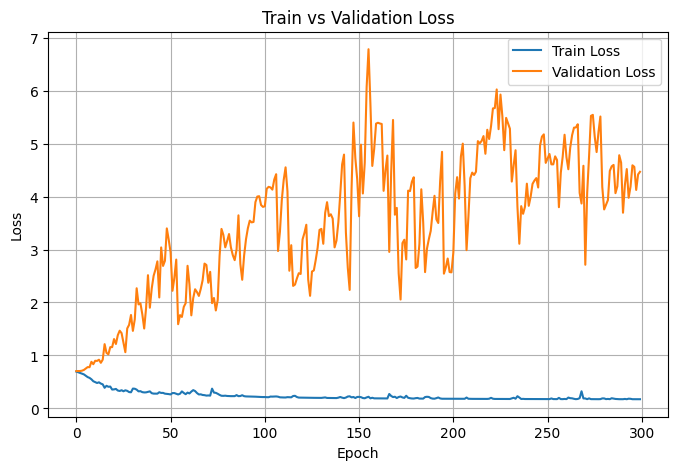

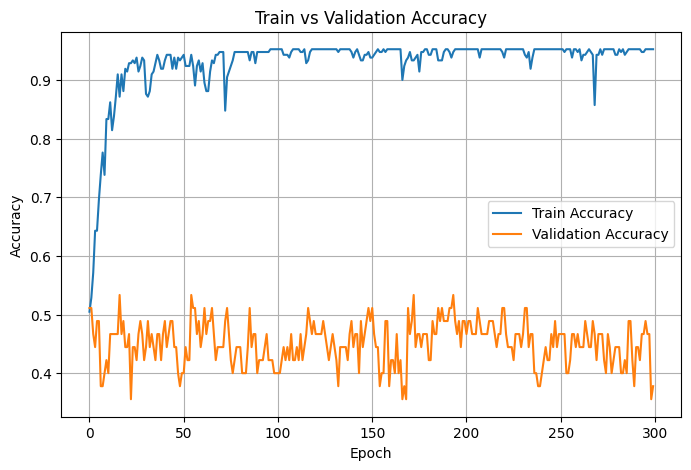


Final Test Loss: 1.0108987092971802
Final Test Accuracy: 0.31111112236976624


In [10]:
import copy
import numpy as np
import matplotlib.pyplot as plt

EPOCHS = 300
PRINT_EVERY = 1

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = -np.inf
best_val_loss = np.inf
best_epoch = 0
best_model_state = None

X_train_t = X_train_t.to(device)
X_val_t = X_val_t.to(device)

y_train_t = y_train_t.to(device)
y_val_t = y_val_t.to(device)

for epoch in range(EPOCHS):
    model.train()

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        train_logits = model(X_train_t)
        val_logits = model(X_val_t)

        train_loss = criterion(train_logits, y_train_t).item()
        val_loss = criterion(val_logits, y_val_t).item()

        train_pred = torch.argmax(train_logits, dim=1)
        val_pred = torch.argmax(val_logits, dim=1)

        train_acc = (train_pred == y_train_t).float().mean().item()
        val_acc = (val_pred == y_val_t).float().mean().item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_loss < best_val_loss):
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    if epoch % PRINT_EVERY == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

print("\nBest Epoch:", best_epoch + 1)
print("Best Val Accuracy:", best_val_acc)
print("Best Val Loss:", best_val_loss)

# Load best validation model
model.load_state_dict(best_model_state)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

X_test_t = X_test_t.to(device)
y_test_t = y_test_t.to(device)

model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)
    test_loss = criterion(test_logits, y_test_t).item()

    test_pred = torch.argmax(test_logits, dim=1)
    test_acc = (test_pred == y_test_t).float().mean().item()

print("\nFinal Test Loss:", test_loss)
print("Final Test Accuracy:", test_acc)